<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/Logistic_regression_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

🔍 Step 2: Locating the training super-dataset...
 Loaded Training Set from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv
Model trained successfully and active in memory.

 Extracting model coefficients for feature importance


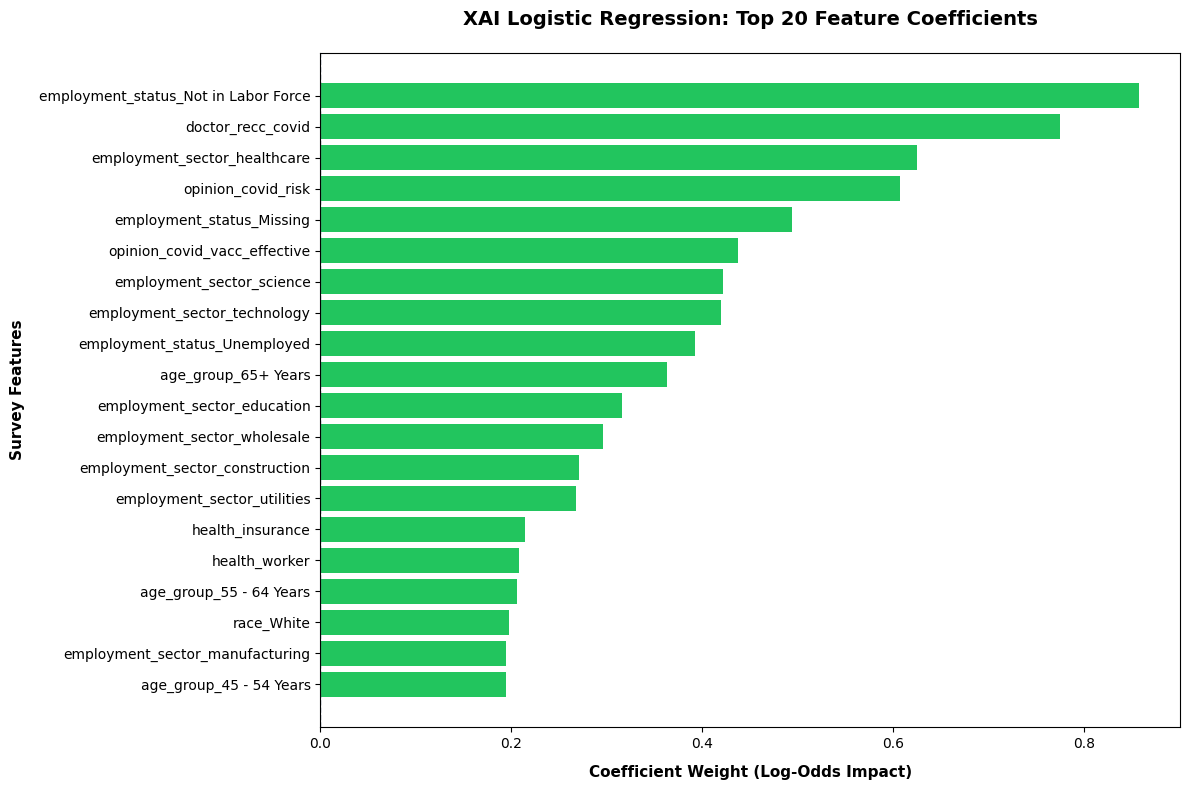

linear coefficient plot exported directly to Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/logistic_regression_xai.png


In [3]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')

#LOAD DATA
print("\n🔍 Step 2: Locating the training super-dataset...")
search_train = '/content/drive/MyDrive/Dataset*C/super_dataset_C_train.csv'
train_files = glob.glob(search_train) or glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(train_files) > 0:
    file_path = train_files[0]
    df_train = pd.read_csv(file_path)
    print(f" Loaded Training Set from: {file_path}")
else:
    raise FileNotFoundError("ERROR: Could not find 'super_dataset_C_train.csv'")

# Isolate features and target labels
y_train_full = df_train['covid_vaccine']
X_train_full = df_train.drop(columns=['covid_vaccine'])

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Standard untuned model using balanced class weights due to data imbalance
base_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
base_lr.fit(X_train, y_train)
print("Model trained successfully and active in memory.")

#extract coeffs fir linear XAI
print("\n Extracting model coefficients for feature importance")

#take coeffs from sing log odd array
coefficients = base_lr.coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values(by='Abs_Coefficient', ascending=False)

#take top 20 most influential features
top_features = coef_df.head(20).copy().sort_values(by='Coefficient', ascending=True)

#export coeff chart
plt.figure(figsize=(12, 8))

#positive : green, negative: red
colors = ['#ef4444' if c < 0 else '#22c55e' for c in top_features['Coefficient']]

plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors, edgecolor='none')
plt.axvline(x=0, color='#64748b', linestyle='--', linewidth=1)

plt.title("XAI Logistic Regression: Top 20 Feature Coefficients", fontweight='bold', fontsize=14, pad=20)
plt.xlabel("Coefficient Weight (Log-Odds Impact)", fontweight='bold', fontsize=11, labelpad=10)
plt.ylabel("Survey Features", fontweight='bold', fontsize=11, labelpad=10)
plt.tight_layout()

#save image
lr_plot_path = file_path.replace('super_dataset_C_train.csv', 'logistic_regression_xai.png')
plt.savefig(lr_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"linear coefficient plot exported directly to Drive folder:\n   {lr_plot_path}")